# Quick Exploration of the Line Fluxes and Line Ratios from EmFit

From notebook `exploring-line-measurements.ipynb` I extracted all the important functions into `src/emline-inspect-functions.py` and I will use them to take a look at the EmFit reported measurements.

In [1]:
%matplotlib widget

In [2]:
%run ../src/emline-inspect-functions.py

NII S/N:  13.046692030102784
N2:  -1.5277227588803604
EmFit catalog N2:  -2.027290876686727


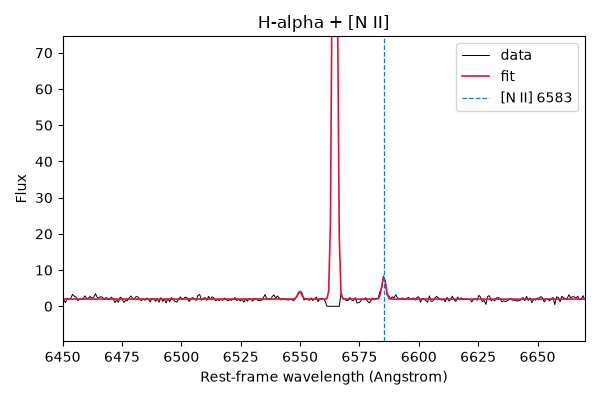

In [3]:
result = plot_ha_nii(2, emps, fignum=1)

In [4]:
emps.iloc[2]

TARGETID             39627666407555924
SPECPROD                       b'iron'
SURVEY                         b'main'
PROGRAM                      b'bright'
HEALPIX                          27177
TARGET_RA                   142.433146
TARGET_DEC                   -5.067068
Z                             0.075279
HB_N_FLUX                    23.650591
HB_N_FLUX_ERR                 0.011252
OIII5007_FLUX                28.693749
OIII5007_FLUX_ERR             0.375611
NII6583_FLUX                 15.443294
NII6583_FLUX_ERR              0.092443
HA_N_FLUX                  1644.488452
HA_N_FLUX_ERR               278.768198
N2                           -2.027291
R3                            0.083945
ston                          167.0567
Name: 2, dtype: object

In [5]:
ex = Table.read('../data/spectra/39627666407555924.fits', format='fits')

/tmp/ipykernel_194391/1445658886.py:6: RuntimeWarning: divide by zero encountered in divide
  err = 1 / np.sqrt(ex['ivar'])


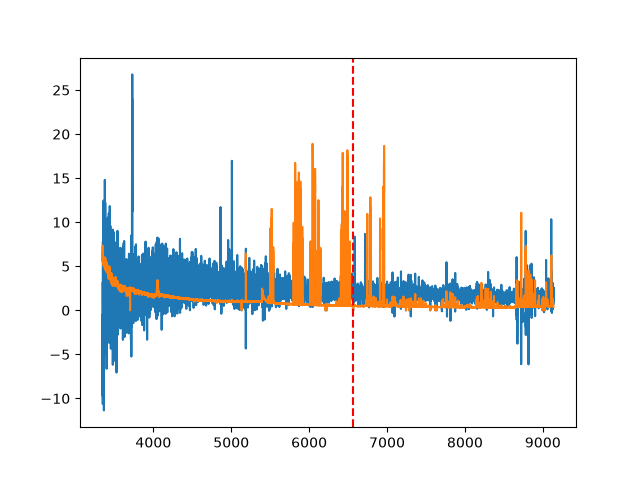

In [6]:
plt.figure(2)
plt.clf()

plt.plot(ex['wavelength'] / (1 + 0.075279), ex['flux'])
# plt.plot(ex['wavelength'] / (1 + 0.075279), ex['flux'], '.', color='r')
err = 1 / np.sqrt(ex['ivar'])
err[np.isinf(err)] = 0
plt.plot(ex['wavelength'] / (1 + 0.075279), err)


plt.axvline(6563, color='r', ls='--')
plt.show()

There seem to be several sources for which Ha fluxes are reported but the line does not show in the spectrum because the uncertainty is inf.

I have an idea, maybe Ha/Hb has to be reasonably close to the Case B value of 2.86.

In [7]:
np.log10(15.443294 / (28.693749 * 2.86))

-0.7254133887460634

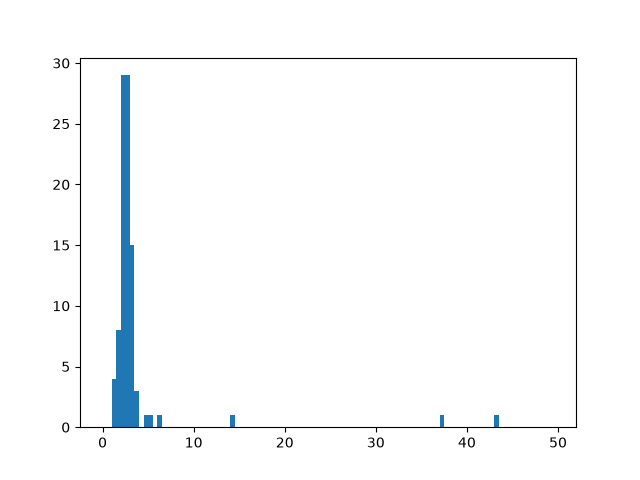

In [8]:
plt.figure(3)
plt.clf()

plt.hist(emps['HA_N_FLUX'] / emps['HB_N_FLUX'], bins=np.arange(0, 50, 0.5))

plt.show()

In [9]:
print(len(emps))
print(np.sum(emps['HA_N_FLUX'] / emps['HB_N_FLUX'] < 10))

112
91


I will use the idea and will require that the Ha/Hb ratio "makes sense".

In [10]:
emps = emps.query('HA_N_FLUX / HB_N_FLUX < 10')

NII S/N:  1.684240554955014e-13
N2:  -14.196339538380226
EmFit catalog N2:  -1.9961005522532818


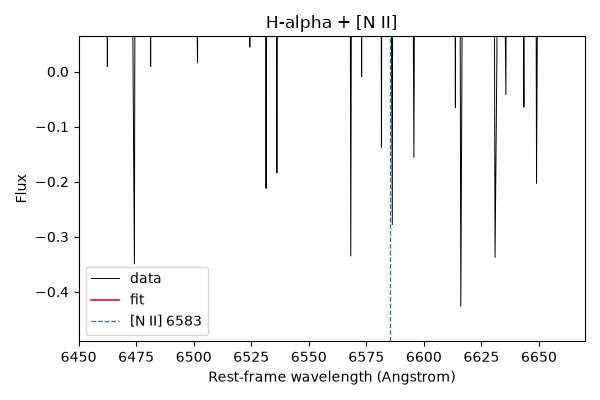

In [11]:
result = plot_ha_nii(20, emps=emps, fignum=4)

My estimate of NII S/N:  7.216849634520674e-10
EmFit estimate of  S/N:  10.100000000000003

My estimate of N2:  -10.67101258445908
EmFit estimate   :  -2.7585229934252635

My estimate of R3:  0.35123790416289713
EmFit estimate   :  0.3268019552692689


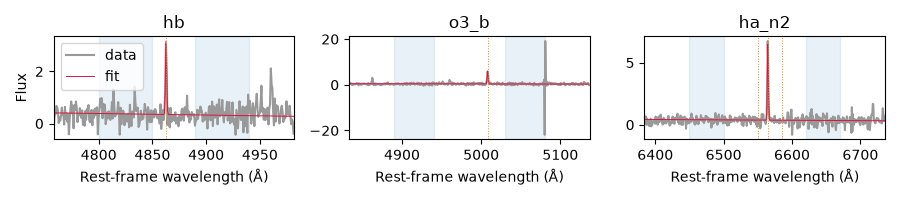

In [12]:
result = report_and_plot(21, emps, fignum=None)